# Getting started with MemsArrayWS objects

The `MemsArrayWS` class allows getting signals from a remote antenna running a local *Megamicros Broadcast Server (MBS)* server. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from megamicros.log import log
from megamicros.core.ws import MemsArrayWS

log.setLevel( "INFO" )

# Set server access credentials
#HOST = 'buzenval20.fr'
#HOST = 'parisparc.biimea.tech
HOST = 'localhost'
PORT = 9002

## Connecting to the remote server

Providing a *MBS* server is running at ``HOST:PORT``, one can try to connect by creating a ``MemsArrayWS`` object.

In [2]:
# Define the antenna
try:
    antenna = MemsArrayWS( HOST, port=PORT )
except Exception as e:
    print( f"Failed: {e}" )


2023-11-04 08:41:41,115 [INFO]:  .Install MemsArrayWS settings
2023-11-04 08:41:41,117 [INFO]:  .Created a new antenna
2023-11-04 08:41:41,118 [INFO]:  .Async event loop already running. Adding coroutine to the event loop...


2023-11-04 08:41:41,126 [INFO]:  .Try connecting to ws://localhost:9002...
2023-11-04 08:41:41,159 [INFO]:  .Received positive answer from server
2023-11-04 08:41:41,160 [INFO]:  .Getting settings values from remote receiver...
2023-11-04 08:41:41,161 [INFO]:  .Received settings from server [ok]
2023-11-04 08:41:41,162 [INFO]:  .Set 8 available MEMs numbered from 0 to 7
2023-11-04 08:41:41,162 [INFO]:  .No analogic channels available
2023-11-04 08:41:41,164 [INFO]:  .Starting MegamicrosWS device [ready]


## Performing a selftest

In [ ]:
# Perform an antenna selftest
antenna.selftest()

2023-11-04 08:41:44,630 [INFO]:  .Connecting to remote host localhost:9002...
2023-11-04 08:41:44,633 [INFO]:  .Connected
2023-11-04 08:41:44,634 [INFO]:  .Send selftest command to server
2023-11-04 08:41:45,180 [INFO]:  .Remote server selftest command successfull


## Halting the remote server
Notice that the conection is lost. As such you could not restart the server.

In [ ]:
# Stop the remote server
antenna.shutdown()


## Running

### Getting signals from some MEMs

In [5]:
# 2 seconds run, getting signals from MEMs 1 and 2
antenna.run(
    mems = [1, 2],
    duration=2,
    buffer_length=512,
    signal_q_size = 0,
)

# Init a np.ndarray
signals = np.ndarray( (0, antenna.channels_number ) )

# Get signals
i = 0
for data in antenna:
    i += 1
    signals = np.concatenate( ( signals, data ), axis=0 )

# waiting for the end of the running thread is mandatory
antenna.wait()
print( f"Exit from loop. Received {i} frames. Signal shape is: {np.shape( signals )}" )

2023-11-04 08:42:12,155 [INFO]:  .Starting run execution
2023-11-04 08:42:12,157 [INFO]:  .Install MemsArray settings
2023-11-04 08:42:12,158 [INFO]:  .2 MEMs were activated among 0 to 7 available MEMs
2023-11-04 08:42:12,159 [INFO]:  .Install MemsArrayWS settings
2023-11-04 08:42:12,160 [INFO]:  .Pre-execution checks for MemsArray.run()
2023-11-04 08:42:12,160 [INFO]:  .Requested job: run
2023-11-04 08:42:12,161 [INFO]:  .Perform a 2s run loop
2023-11-04 08:42:12,162 [INFO]:  .H5 recording off
2023-11-04 08:42:12,163 [INFO]:  .Start a `run` running job on remote server
2023-11-04 08:42:12,163 [INFO]:  .Background execution mode off
2023-11-04 08:42:12,164 [INFO]:  .Run thread execution started
2023-11-04 08:42:12,164 [INFO]:  .Starting iterations: will produce data as numpy array of int32 (256 x 2 size)
2023-11-04 08:42:12,165 [INFO]:  .Connecting to remote host localhost:9002...
2023-11-04 08:42:12,169 [INFO]:  .Connected
2023-11-04 08:42:12,170 [INFO]:  .Send running job command (ru

Exit from loop. Received 384 frames. Signal shape is: (98304, 2)


## Plotting signals

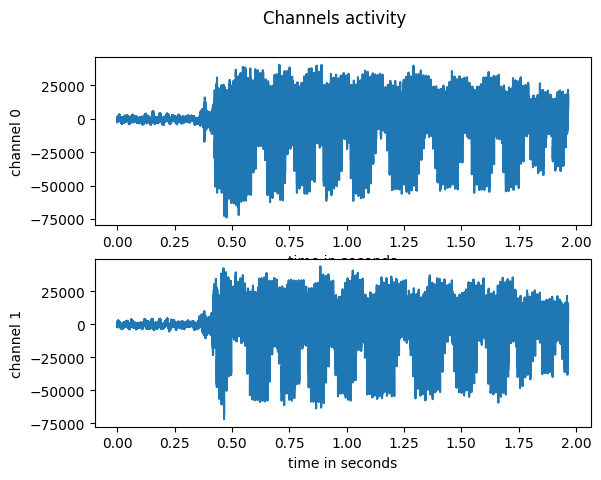

In [6]:
# plot signals
time = np.array( range( np.size(signals,0) ) )/antenna.sampling_frequency
fig, axs = plt.subplots( antenna.channels_number )
fig.suptitle('Channels activity')	
for s in range( antenna.channels_number ):
    axs[s].plot( time, signals[:,s] )
    axs[s].set( xlabel='time in seconds', ylabel='channel %d' % s )

plt.show()

## Saving signals as wav file
Since wavfiles are audio files, you cannot save more than 2 channels.

In [ ]:
import wave

WAV_FILENAME = 'toto.wav'

# 2 seconds run, getting signals from MEMs 1 and 2
antenna.run(
    mems = [1, 2],
    duration=10,
    buffer_length=512,
    signal_q_size = 0,
)

with  wave.open( WAV_FILENAME, mode='wb' ) as wavfile:
    wavfile.setnchannels(2)
    wavfile.setsampwidth(2)
    wavfile.setframerate( antenna.sampling_frequency )

    # Get signals
    for data in antenna:
        signal = data >> 4
        wavfile.writeframesraw( np.int16( np.reshape( signal, np.size( signal ), order='F' ) ) )

# waiting for the end of the running thread is mandatory
antenna.wait()

## Hearing signal with *pyaudio* library

Note that `signal_q_size` is set to 0, setting the internal queue to an infinite length.
This prevents breaks in the audio stream.

In [ ]:
import pyaudio

FRAME_LENGTH = 512
SAMPLING_FREQUENCY = 50000
antenna.setSamplingFrequency( SAMPLING_FREQUENCY )

# Instantiate PyAudio and initialize PortAudio system resources (1)
p = pyaudio.PyAudio()

# Open stream
stream = p.open(
    format = pyaudio.paFloat32,
    channels = 2,
    rate = int( antenna.sampling_frequency ),
    output=True,
    frames_per_buffer=FRAME_LENGTH,
)

# Start running the remote Megamicros system
antenna.run( 
    mems=[3, 4],
    duration=10,
    frame_length=FRAME_LENGTH,
    counter_skip = True,
    signal_q_size = 0
)

# Get signals
transfers_counter = 0
for data in antenna:
    signal = data >> 4

    # convert into float and normalize with MEMs sensibility
    data = ( data.astype( np.float32 ).T * antenna.sensibility )

    # write into audio stream
    stream.write( data, num_frames=FRAME_LENGTH )
    transfers_counter += 1

# Close stream and release PortAudio system resources (5)
stream.close()            
p.terminate()

antenna.wait()


## Saving signals as H5 files

You can save signal in H5 file format. In this example sigansl are saved on the MBS remote server.
The antenna receive no more signals. 

In [ ]:
antenna.run(
    mems = [3, 4],
    duration=2,
    buffer_length=512,
    h5_recording=True,                          # H5 recording ON
    h5_pass_through=True,                       # perform F5 recording on server
    h5_rootdir='./',                            # directory where to save file
    h5_compressing=False,                       # Use compression or not
    background_mode=True,
    signal_q_size = 0,
)

antenna.wait()

## Getting signals yourself

In this example, signals are received using the antenna internal queue.

In [ ]:
import queue

antenna.run(
    mems = [1, 2],
    duration=2,
    buffer_length=512,
    signal_q_size = 0,
)

i = 0
while True:
    try:
        data = antenna.signal_q.get( timeout=5 )
        print( f"[{i}]" )
        i += 1
        # do what you want with data...

    except queue.Empty:
        print( f"exit from loop at i={i}" )
        break

antenna.wait()

## Listening to the Megamicro remote server
By starting a *master* run on the server, you can connect to the server from others hosts and listening to the signal stream.

### Staring the master run
This call lets the remote server starting a run in the background mode.

In [ ]:

antenna.run(
    mems = [1, 2, 3, 4],
    duration=0,
    buffer_length=512,
    signal_q_size=0,
    job='master', 
)

2023-11-04 08:51:39,726 [INFO]:  .Starting run execution
2023-11-04 08:51:39,728 [INFO]:  .Install MemsArray settings
2023-11-04 08:51:39,729 [INFO]:  .4 MEMs were activated among 0 to 7 available MEMs
2023-11-04 08:51:39,730 [INFO]:  .Install MemsArrayWS settings
2023-11-04 08:51:39,730 [INFO]:  .Pre-execution checks for MemsArray.run()
2023-11-04 08:51:39,731 [INFO]:  .Requested job: master
2023-11-04 08:51:39,732 [INFO]:  .Run infinite loop (duration=0)
2023-11-04 08:51:39,732 [INFO]:  .H5 recording off
2023-11-04 08:51:39,733 [INFO]:  .Start a `master` running job on remote server
2023-11-04 08:51:39,733 [INFO]:  .Background execution mode off
2023-11-04 08:51:39,735 [INFO]:  .Run thread execution started
2023-11-04 08:51:39,736 [INFO]:  .Connecting to remote host localhost:9002...


2023-11-04 08:51:39,740 [INFO]:  .Connected
2023-11-04 08:51:39,741 [INFO]:  .Send running job command (master)
2023-11-04 08:51:39,743 [INFO]:  .Master run command accepted by server
2023-11-04 08:51:41,744 [INFO]:  .Halt connection with server and exit


In [ ]:
# Define the antenna
try:
    listener = MemsArrayWS( HOST, port=PORT )
except Exception as e:
    print( f"Failed: {e}" )


2023-11-04 08:44:47,210 [INFO]:  .Install MemsArrayWS settings
2023-11-04 08:44:47,212 [INFO]:  .Created a new antenna
2023-11-04 08:44:47,213 [INFO]:  .Async event loop already running. Adding coroutine to the event loop...


2023-11-04 08:44:47,217 [INFO]:  .Try connecting to ws://localhost:9002...
2023-11-04 08:44:47,220 [INFO]:  .Received positive answer from server
2023-11-04 08:44:47,221 [INFO]:  .Getting settings values from remote receiver...
2023-11-04 08:44:47,222 [INFO]:  .Received settings from server [ok]
2023-11-04 08:44:47,223 [INFO]:  .Set 8 available MEMs numbered from 0 to 7
2023-11-04 08:44:47,223 [INFO]:  .No analogic channels available
2023-11-04 08:44:47,225 [INFO]:  .Starting MegamicrosWS device [ready]


In [13]:
listener.setFrameLength(512)
listener.run(
    mems = [1, 2],
    buffer_length=512,
    signal_q_size=0,
    duration=2,
    job='listen'
)

# Init a np.ndarray
signals = np.ndarray( (0, listener.channels_number ) )

# Get signals
i = 0
for data in listener:
    i += 1
    signals = np.concatenate( ( signals, data ), axis=0 )
    print( data )

# waiting for the end of the running thread is mandatory
listener.wait()
print( f"Exit from loop. Received {i} frames. Signal shape is: {np.shape( signals )}" )

2023-11-04 08:51:54,823 [INFO]:  .Starting run execution
2023-11-04 08:51:54,825 [INFO]:  .Install MemsArray settings
2023-11-04 08:51:54,826 [INFO]:  .2 MEMs were activated among 0 to 7 available MEMs
2023-11-04 08:51:54,827 [INFO]:  .Install MemsArrayWS settings
2023-11-04 08:51:54,828 [INFO]:  .Pre-execution checks for MemsArray.run()
2023-11-04 08:51:54,829 [INFO]:  .Requested job: listen
2023-11-04 08:51:54,829 [INFO]:  .Perform a 2s run loop
2023-11-04 08:51:54,831 [INFO]:  .H5 recording off
2023-11-04 08:51:54,832 [INFO]:  .Start a `listen` running job on remote server
2023-11-04 08:51:54,833 [INFO]:  .Background execution mode off
2023-11-04 08:51:54,834 [INFO]:  .Run thread execution started
2023-11-04 08:51:54,835 [INFO]:  .Starting iterations: will produce data as numpy array of int32 (512 x 2 size)
2023-11-04 08:51:54,836 [INFO]:  .Connecting to remote host localhost:9002...
2023-11-04 08:51:54,841 [INFO]:  .Connected
2023-11-04 08:51:54,842 [INFO]:  .Send running job comma

[[ -730   892]
 [  244   716]
 [-1396  -552]
 ...
 [ -689  -517]
 [-1321 -1428]
 [ -147  -214]]
[[ -920  -567]
 [  601   772]
 [-1449  1702]
 ...
 [   27  2093]
 [-2520   631]
 [  -11  -174]]
[[1263 -120]
 [ 941  581]
 [1863  388]
 ...
 [ 766  -89]
 [1945  920]
 [ 318 -796]]
[[ -368   893]
 [  861   603]
 [-1166  -798]
 ...
 [  474    -9]
 [  735   799]
 [ -153  1244]]
[[ 1497  -247]
 [  665   -29]
 [ -535   243]
 ...
 [  -87   572]
 [  487  -747]
 [-1171    47]]
[[  431  -390]
 [ -659  -413]
 [  288  -209]
 ...
 [  446  -128]
 [ -606 -1433]
 [ -764 -1950]]
[[-1518  -226]
 [ -836  -808]
 [ -480   482]
 ...
 [ -257  -915]
 [-1079 -1777]
 [  417   196]]
[[ -201 -1673]
 [ -928 -3229]
 [-2276 -1448]
 ...
 [-2537  -653]
 [-2614 -3711]
 [ -281  -896]]
[[-1676 -1483]
 [-2285 -2536]
 [ -925 -2212]
 ...
 [-1161 -2566]
 [-1892 -3745]
 [-2804 -1729]]
[[-2394  -932]
 [-2654  -566]
 [-2317  1462]
 ...
 [  -41  1208]
 [-1292   -26]
 [  332 -1976]]
[[ 215  -65]
 [-181 1085]
 [ 313  -18]
 ...
 [ 745  

2023-11-04 08:51:56,837 [INFO]:  .Thread timer started for 2s duration
2023-11-04 08:51:56,858 [INFO]:  .Send stop command
2023-11-04 08:51:56,860 [INFO]:  .Received aknowledgment reponse from halt request. Stop running.


[[ 2859 -1114]
 [ 2618   467]
 [  607  -210]
 ...
 [  130  -769]
 [ -222  1009]
 [ -732  1628]]
[[-161 -202]
 [ 139  876]
 [ 118 2026]
 ...
 [ 856 -862]
 [1060  -25]
 [1375 -259]]
[[ -765  -958]
 [  429   817]
 [ -751  -818]
 ...
 [ -166   858]
 [  568   959]
 [ -872 -1996]]
[[ 1527   670]
 [  -52 -2499]
 [ -254   195]
 ...
 [  432 -1428]
 [ 1455  -875]
 [-1250 -2247]]
[[-1221  -430]
 [-2070   251]
 [-2591   371]
 ...
 [ 1152   657]
 [ 1435  2016]
 [  855  1645]]
[[  522 -1088]
 [  -49 -1579]
 [   26 -2292]
 ...
 [-1049    90]
 [ -560   897]
 [-1547  -617]]
[[ 982 1349]
 [-701 -231]
 [ 544 1003]
 ...
 [ 464  704]
 [-129 -533]
 [-528 1006]]
[[  549  -323]
 [  364   650]
 [ 1945 -1164]
 ...
 [ -889  -627]
 [ -893 -1653]
 [ -694   992]]
[[  -68   328]
 [  499  -772]
 [  107 -1510]
 ...
 [-1402 -2290]
 [ -555 -1898]
 [ -213 -2068]]
[[-1044 -1220]
 [-1626 -1362]
 [ -516  -633]
 ...
 [-1223 -1465]
 [-2582  -739]
 [  124   445]]
[[-1090   631]
 [ -332  -133]
 [-1512   218]
 ...
 [-1077   683]

In [ ]:
# halt job
antenna.halt()

2023-11-04 08:52:06,714 [INFO]:  .Connecting to remote host localhost:9002...
2023-11-04 08:52:06,717 [INFO]:  .Connected
2023-11-04 08:52:06,719 [INFO]:  .Send halt command...


2023-11-04 08:52:08,711 [INFO]:  .Halt command completed


In [ ]:
# halt server
antenna.shutdown()

2023-11-04 08:52:26,527 [INFO]:  .Async event loop already running. Adding coroutine to the event loop...


2023-11-04 08:52:26,531 [INFO]:  .Connecting to remote host localhost:9002...
2023-11-04 08:52:26,534 [INFO]:  .Connected
2023-11-04 08:52:26,535 [INFO]:  .Send shutdown command to server
2023-11-04 08:52:26,537 [INFO]:  .Remote server shutdown success
